# Import Function

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

# Helper Functions

In [47]:
def weibull_pdf(t, k, lambda_):
    """Weibull Function (PDF)"""
    return (k / lambda_) * (t / lambda_)**(k - 1) * np.exp(-(t / lambda_)**k)

def weibull_cdf(t, k, lambda_):
    """Weibull CDf"""
    return 1 - np.exp(-(t / lambda_)**k)

def derivative_survival(t, k, lambda_):
    """The derivative of the survival function is simply the negative of the weibull_pdf"""
    return -weibull_pdf(t, k, lambda_)

def compute_lambda(k, mu, num_points=10000):
    """Computes lambda for a given k value."""
    s = np.linspace(0.001, 200, num_points)  # avoid zero to prevent division issues
    integrand = s**(1/k) * np.exp(-s)
    integral = np.trapz(integrand, s)
    lambd = mu / integral
    return lambd

def inverse_survival_newton(alpha, k, lambd, tol=1e-5, max_iter=100):
    """Perform's Newton's method where f is the survival function - alpha (if equated to zero) and f' is the negative of weibull."""
    t = 50 # guess
    for _ in range(max_iter):
        surv = 1 - weibull_cdf(t, k, lambd)
        f = surv - alpha
        if np.abs(f) < tol:
            return t
        df = derivative_survival(t, k, lambd)
        if df == 0:
            break
        # Newton's method iteration
        t -= f / df
        t = max(t, 1e-5) # t is clipped to avoid having negative t

    print(f'final {t}')
    return t

# Analytical Discussion

The problem requires to compare the inverse survival function of Weibull distribution for different values of k (shape parameter) and how risks affect survival over time. This involves survival analysis basics in which Cumulative Distribution Function, Probability Density Function, survival function, and inverse survival function are used in describing the probabilities of a certain event. 

Given formulas

## Probability Density Function (PDF):
$$
\text{PDF}(t) = \frac{k}{\lambda} \left( \frac{t}{\lambda} \right)^{k-1} \exp{\left(-\frac{t}{\lambda} k \right)}
$$

## Cumulative Distribution Function (CDF):
$$
\text{CDF}(t) = \int_{-\infty}^{t} \text{PDF}(s) ds = \int_{-\infty}^{t} \frac{k}{\lambda} \left( \frac{s}{\lambda} \right)^{k-1} \exp{\left(-\frac{s}{\lambda} k \right)} ds
$$

Since the function has a lower limit of $-\infty$, the intergration will be equal to zero when $t<0$. Hence, let us assume that $t \geq 0$ so that the limits become 0 to $t$.

Rewriting to the equation
$$
\text{CDF}(t) = \int_0^t \left( \frac{k(\frac{t}{\lambda})^{k-1} \exp{(-\frac{t}{\lambda}k)}}{\lambda} \right) dt \\
\text{CDF}(t) = \int_0^t \left( \frac{k(t)^{k-1} \exp{(-\frac{t}{\lambda}k)}}{\lambda^k} \right) dt 
$$

Let
$$
u = -\frac{t^k}{\lambda^k}\\
du = -\frac{kt^{k-1}}{\lambda^k}\\
\text{CDF}(t) = -\int_0^t e^u du = -e^u |_0^t = -e^{-\frac{t^k}{\lambda^k}} |_0^t \\
\text{CDF}(t) = 1 - e^{-\frac{t^k}{\lambda^k}}
$$

## Survival Function S(t):
$$
S(t) = 1 - \text{CDF}(t) = 1 - (1 - e^{-\frac{t^k}{\lambda^k}}) = e^{(-\frac{t}{\lambda})^k}
$$

## Inverse Survival Function:
$$
S^{-1}(\alpha) = t ~\text{such that}~S(t) = \alpha
$$

Therefore,
$$
S(t) = e^{(-\frac{t}{\lambda})^k} = \alpha \\
\ln(\alpha) = \ln(e^{(-\frac{t}{\lambda})^k}) = (-\frac{t}{\lambda})^k
$$

Since $S^{-1}(\alpha) = t$, the equation will be
$$
-\ln(\alpha) = (\frac{t}{\lambda})^k \\
\frac{t}{\lambda} = (-\ln(\alpha))^{\frac{1}{k}} \\
t = \lambda (-\ln(\alpha))^{\frac{1}{k}}
$$

Using the expected value of the Weibull distribution to produce a final expression that relates $\lambda$ and $\mu$ through the gamma function 
$$
\lambda = \frac{\mu}{\int_0^{\infty} s^{\frac{1}{k}} e^{-s} ds}
$$

Solving for the $\int_0^{\infty} s^{\frac{1}{k} e^{-s}} ds$ first will yield a gamma function integral that matches the Weibull distribution.

$$
I = \int_0^{\infty} s^{\frac{1}{k}} e^{-s} ds
$$

Transforms into
$$
\Gamma(\alpha) = \int_0^{\infty} s^{\alpha-1} e^{-s} ds ~\text{for}~ \alpha > 0 \\
s^{\frac{1}{k}} = s^{\alpha-1} \\
\alpha - 1 = \frac{1}{k} \\
\alpha = 1 + \frac{1}{k}
$$

Expressing the integral in terms of $\Gamma$
$$
I = \int_0^{\infty} s^{\frac{1}{k}} e^{-s} ds = \Gamma(\alpha) = \Gamma(1 + \frac{1}{k})
$$
$\lambda$ will now be equal to
$$
\lambda = \frac{\mu}{\Gamma(1 + \frac{1}{k})}
$$

This equation is now solvable through given $\mu=78$ years and for each value of $k$. After the operation of the gamma function, the inverse survival function will now be generated using the formula $t=-\lambda(-\ln{\alpha})^{1/k} ~\text{for}~ \alpha \in (0, 1)$. Lastly, the plot can bow be displayed by $k = 0.5$ (decreasing death rate), $k = 1$ (constant death rate) and $k = 2$ (increasing death rate).

In [56]:
matlab_code = """MATLAB Code 

% Set desired mean age 
mean_age = 78; 

% Define the different k values you want to plot 
k_values = [0.5, 1, 2]; 

% Create a figure 
figure; 
hold on;

% Generate distinct colors for each curve
colors = lines(length(k_values)); 

for i = 1:length(k_values)
    k = k_values(i);     
    % Calculate the scale parameter lambda for each k     
    lambda = mean_age / gamma(1 + 1 / k);
    % Generate survival probabilities     
    alpha = linspace(0.001, 0.999, 500);          
    % Compute ages corresponding to survival probabilities     
    ages = lambda * (-log(alpha)).^(1 / k);          
    % Plot each curve     
    plot(alpha, ages, 'LineWidth', 2, 'Color', colors(i, :), ...         
    'DisplayName', ['k = ', num2str(k)]); 
end 

xlabel('Survival probability \alpha'); 
ylabel('Age at survival probability \alpha'); 
title('Inverse Weibull Survival Functions for Different k Values'); 
legend('show'); 
grid on; 
hold off; """
print(matlab_code)

MATLAB Code 

% Set desired mean age 
mean_age = 78; 

% Define the different k values you want to plot 
k_values = [0.5, 1, 2]; 

% Create a figure 
figure; 
hold on;

% Generate distinct colors for each curve
colors = lines(length(k_values)); 

for i = 1:length(k_values)
    k = k_values(i);     
    % Calculate the scale parameter lambda for each k     
    lambda = mean_age / gamma(1 + 1 / k);
    % Generate survival probabilities     
    alpha = linspace(0.001, 0.999, 500);          
    % Compute ages corresponding to survival probabilities     
    ages = lambda * (-log(alpha)).^(1 / k);          
    % Plot each curve     
    plot(alpha, ages, 'LineWidth', 2, 'Color', colors(i, :), ...         
    'DisplayName', ['k = ', num2str(k)]); 
end 

xlabel('Survival probability lpha'); 
ylabel('Age at survival probability lpha'); 
title('Inverse Weibull Survival Functions for Different k Values'); 
legend('show'); 
grid on; 
hold off; 


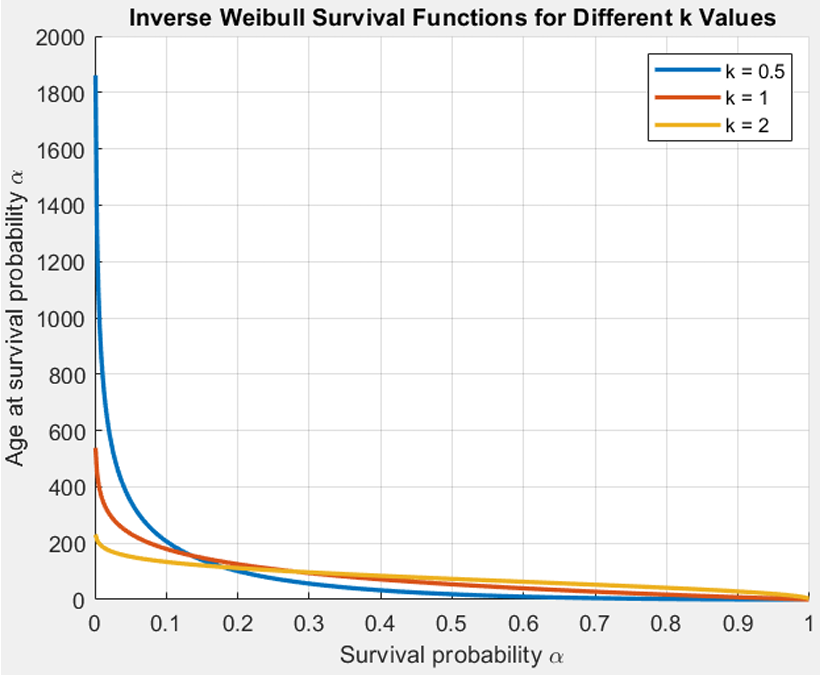

In [53]:
Image("images/matlab_inverse_weibull.png")

Shown here is the plot generated by Matlab using the analytical solution.

# Numerical Solution
For this version of solution, Newton's method is utilized to solve. The root finding scheme is defined below:
F is the survival function which is $1 - CDF(t)$ and the derivative of F is the negative of the PDF(t) by Fundamental Theorem of Calculus.
$$
F(t) = 1 - CDF(t) - \alpha = 1 - \int_{-\infty}^{t} \frac{k}{\lambda} \left( \frac{s}{\lambda} \right)^{k-1} \exp{\left(-\frac{s}{\lambda} k \right)} ds - \alpha = e^{(-\frac{t}{\lambda})^k} - \alpha \\
F'(t) = - \frac{k}{\lambda} \left( \frac{t}{\lambda} \right)^{k-1} \exp{\left(-\frac{t}{\lambda} k \right)}
$$

And the iterative Newton's Method is as shown:
$$
t^{(n+1)} = t^{(n)} - \frac{F(t^{(n)})}{F'(t^{(n)})}
$$

In [54]:
mu = 78
alphas = np.linspace(0.001, 0.999, 500)
results_newton = {}
for k in [0.5, 1, 2]:
    lambda_ = compute_lambda(k, mu)
    inverse_vals_newton = [inverse_survival_newton(alpha, k, lambda_) for alpha in alphas]
    results_newton[k] = inverse_vals_newton
    print(f'done {k}')
    print()

done 0.5

done 1

done 2



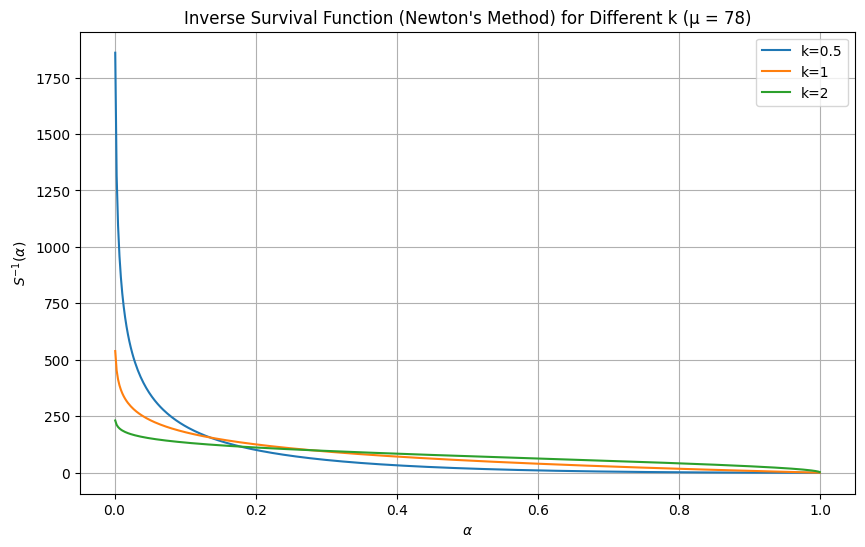

In [55]:
plt.figure(figsize=(10, 6))
for k, vals in results_newton.items():
    plt.plot(alphas, vals, label=f'k={k}')
plt.title('Inverse Survival Function (Newton\'s Method) for Different k (μ = 78)')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$S^{-1}(\alpha)$')
plt.legend()
plt.grid(True)
plt.show()

# Interpretation

From the actuary, knowing how long policyholders are expected to live will help creating accurate predictions and manage risks. The graph illustrates the likelihood of survival to various ages changes under an inverse Weibull model with different shape parameter (simply which certain percentage of people are still alive).  

One can observe that as you move from left to the right, the age decreases as survival probability increases. A lower value of parameter $k (k = 0.5)$ indicates higher early mortality, a parameter equal to 1 means constant while higher $k (k = 2)$ shows that the ages are closer to the mean with increasing probability. It is also important to highlight that the parameter k affects the pattern of survival probability 𝛼 across age, shaping the survival function presented in the graph. 